In [3]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df=sns.load_dataset('titanic')

In [7]:
df.shape

(891, 15)

In [9]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [11]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [13]:
df.dropna().shape # Here by default axis=0 which means deleting rows where null values are there but our total rows are 892 and left over are 182 so not a good option to delete the rows

(182, 15)

In [17]:
df.dropna(axis=1) # Here axis=1 means deleting columns with null values as the age has 177 deck has 688 missing values we can delete them

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


# Imputation methods
### 1. Mean Imputation - Used when the data is normally distributed

Text(0.5, 1.0, 'Detection of Normal dis for mean imputation')

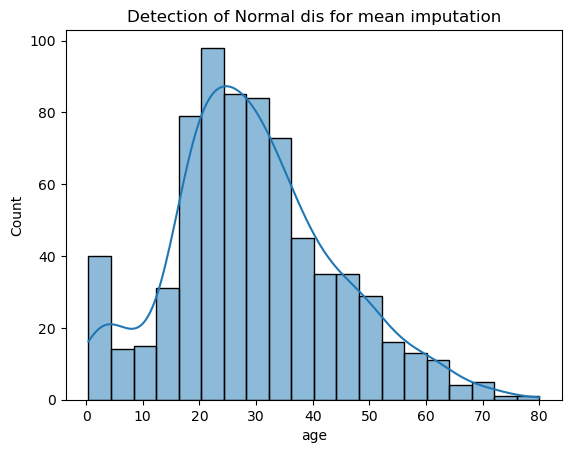

In [22]:
sns.histplot(df['age'],kde=True)
plt.title('Detection of Normal dis for mean imputation')

In [26]:
df['Age_mean'] = df['age'].fillna(df['age'].mean())
df[['Age_mean','age']]

,Age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


### 2. Median imputation - Used when data is **NOT** normally distributed also it can be left skewed or right skewed , also outliers are present

In [33]:
df['Age_median'] = df['age'].fillna(df['age'].median())

In [35]:
df[['Age_median','Age_mean','age']]

,Age_median,Age_mean,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


### 3. Mode imputation - Mostly used in case of categorical values

In [52]:
df['embarked'].isnull().sum()

2

In [54]:
df['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [76]:
mode_value = df[df['embarked'].notna()]['embarked'].mode()[0]

In [80]:
df['embarked']=df['embarked'].fillna(mode_value)

In [82]:
df['embarked'].isnull().sum()

0